In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
data = pd.read_csv('/Users/danielqian/Downloads/dataset copy.csv')
data.columns

Index(['ID', 'region', 'age', 'sex', 'edu', 'educat', 'marry', 'marrycat',
       'income', 'incomecat', 'smoking', 'smokingcat', 'drinking',
       'drinkingcat', 'Height', 'Weight', 'BMI', 'SBP', 'DBP', 'TC', 'TG',
       'HDLC', 'LDLC', 'BMIcat1', 'EX1', 'EX2', 'pm25ave5', 'pm10ave5',
       'no2ave5', 'outcome'],
      dtype='object')

In [4]:
for col in data.select_dtypes(include='object').columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')
correlations = data.corrwith(data['outcome'])
correlations

ID             0.104215
region         0.107502
age            0.274188
sex           -0.008333
edu           -0.127770
educat        -0.112163
marry          0.014940
marrycat       0.061630
income        -0.069332
incomecat     -0.067075
smoking       -0.028291
smokingcat    -0.007197
drinking       0.007696
drinkingcat    0.014967
Height        -0.060327
Weight         0.160229
BMI            0.237067
SBP            0.726739
DBP            0.629946
TC             0.153641
TG             0.123761
HDLC          -0.076654
LDLC           0.119263
BMIcat1        0.189955
EX1           -0.077872
EX2           -0.025756
pm25ave5       0.120864
pm10ave5       0.127483
no2ave5        0.116656
outcome        1.000000
dtype: float64

In [5]:
# logistic regression
X = data[['pm25ave5', 'pm10ave5', 'no2ave5', 'age', 'SBP', 'DBP']]
y = data['outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
log_model = LogisticRegression(class_weight = 'balanced')
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_train)
precision = precision_score(y_train, y_pred)
print(precision)
recall = recall_score(y_train, y_pred)
print(recall)

0.7707238892351527
0.8731968122667205


In [6]:
# random forest
rf_model = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_train)
rf_precision = precision_score(y_train, rf_pred)
rf_recall = recall_score(y_train, rf_pred)
print(rf_precision)
print(rf_recall)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_train, rf_model.predict(X_train)))

0.9993948562783661
0.999596489458287
[[20589     6]
 [    4  9909]]


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val = cross_val_score(rf_model, X, y, cv=cv, scoring='precision')
cross_val

array([0.97370937, 0.97216891, 0.97828185, 0.97647059, 0.98278336])

In [8]:
cross_val_recall = cross_val_score(rf_model, X, y, cv = cv, scoring = 'recall')
cross_val_recall

array([0.8217023 , 0.81726503, 0.81799839, 0.80387409, 0.82929782])

In [9]:
from sklearn.model_selection import cross_validate

scores = cross_validate(rf_model, X, y, scoring = 'f1', return_train_score=True)
df_scores = pd.DataFrame(scores)
df_scores

,fit_time,score_time,test_score,train_score
0,2.553884,0.064044,0.806951,0.999697
1,2.462982,0.056184,0.881065,0.999445
2,2.532106,0.044058,0.541036,0.999546
3,2.596498,0.069961,0.724875,0.999496
4,2.540795,0.054280,0.620634,0.999496


here is where i started to address the overfitting by tuning hyperparameters

In [10]:
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': np.arange(1, 11)}
grid_search = GridSearchCV(rf_model, param_grid, cv=cv, scoring= 'f1', return_train_score=True, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])},
             return_train_score=True, scoring='f1', verbose=1)

In [11]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.492890,0.015551,0.014556,0.000304,1,{'max_depth': 1},0.840787,0.825182,0.835383,0.821291,...,0.832007,0.007469,10,0.830623,0.833582,0.836666,0.831318,0.836946,0.833827,0.002623
1,0.639788,0.001838,0.019735,0.000421,2,{'max_depth': 2},0.872999,0.854475,0.863756,0.854692,...,0.863664,0.008104,9,0.864323,0.863212,0.868055,0.861732,0.868048,0.865074,0.002566
2,0.779268,0.003002,0.025407,0.001487,3,{'max_depth': 3},0.885021,0.865985,0.872611,0.865476,...,0.873886,0.007751,8,0.875439,0.876217,0.878207,0.873634,0.876610,0.876021,0.001497
3,0.921142,0.005520,0.028950,0.000357,4,{'max_depth': 4},0.889722,0.872340,0.877014,0.876683,...,0.881049,0.007178,7,0.881100,0.880788,0.883503,0.882046,0.885379,0.882563,0.001696
4,1.046051,0.005478,0.034578,0.001522,5,{'max_depth': 5},0.895957,0.886700,0.884858,0.879826,...,0.888164,0.005858,6,0.886834,0.891864,0.893004,0.887525,0.889572,0.889760,0.002389
5,1.167760,0.006632,0.037508,0.000459,6,{'max_depth': 6},0.899810,0.885832,0.888214,0.885345,...,0.890808,0.005632,5,0.892511,0.895217,0.895543,0.894561,0.892997,0.894166,0.001205
6,1.281733,0.009758,0.042506,0.000658,7,{'max_depth': 7},0.901316,0.890551,0.889753,0.889753,...,0.893718,0.004721,1,0.894689,0.897289,0.898168,0.897459,0.896127,0.896747,0.001220
7,1.382288,0.007487,0.047953,0.000888,8,{'max_depth': 8},0.900601,0.888273,0.888704,0.888027,...,0.892219,0.005029,3,0.896656,0.899152,0.899752,0.900021,0.898032,0.898723,0.001239
8,1.497517,0.006437,0.052278,0.000229,9,{'max_depth': 9},0.900027,0.889564,0.887106,0.888889,...,0.892261,0.004848,2,0.900778,0.902122,0.902509,0.903089,0.901436,0.901987,0.000809
9,1.594212,0.013564,0.056704,0.000459,10,{'max_depth': 10},0.898669,0.887538,0.886672,0.889504,...,0.891450,0.004598,4,0.904367,0.905213,0.906391,0.907683,0.905098,0.905750,0.001164


In [12]:
pd.set_option('display.float_format', '{:.6f}'.format) 
cv_results[["mean_test_score", "mean_train_score"]]

,mean_test_score,mean_train_score
0,0.832007,0.833827
1,0.863664,0.865074
2,0.873886,0.876021
3,0.881049,0.882563
4,0.888164,0.889760
5,0.890808,0.894166
6,0.893718,0.896747
7,0.892219,0.898723
8,0.892261,0.901987
9,0.891450,0.905750


In [13]:
# print out the best hyperparameters and the best score
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'max_depth': 7}
0.893717949153252
RandomForestClassifier(class_weight='balanced', max_depth=7, random_state=42)


8/4, grid search cv to tune hyperparameters, going to try xgboost and maybe stacking

In [14]:
# xgboost
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.5, 3.0),  # handle class imbalance
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1 = cross_val_score(model, X, y, cv=cv, scoring=make_scorer(f1_score), n_jobs=-1)

    return f1.mean()

# Create Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

# Print best result
print("Best F1 Score:", study.best_value)
print("Best Params:", study.best_params)

/Users/danielqian/anaconda3/envs/stat303_conda_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-08-25 12:53:07,499] A new study created in memory with name: no-name-02665ef9-10b2-4c5c-9696-0927121ec544
[I 2025-08-25 12:53:13,334] Trial 5 finished with value: 0.8838765734620331 and parameters: {'n_estimators': 246, 'max_depth': 3, 'learning_rate': 0.04629245437433191, 'subsample': 0.9412196622707755, 'colsample_bytree': 0.7182444901563251, 'gamma': 0.6180430595991843, 'reg_alpha': 8.374526405069627, 'reg_lambda': 2.2824257349804635, 'scale_pos_weight': 2.5234582391375193}. Best is trial 5 with value: 0.8838765734620331.
[I 2025-08-25 12:53:14,370] Trial 6 finished with value: 0.8786147857957728 and parameters: {'n_estimators': 181, 'max_depth': 3, 'learning_rate': 0.019898560044586993, 'subsam

Best F1 Score: 0.8956376332689329
Best Params: {'n_estimators': 303, 'max_depth': 8, 'learning_rate': 0.010249590425995317, 'subsample': 0.8388449960738497, 'colsample_bytree': 0.9201329924593438, 'gamma': 4.276821614574383, 'reg_alpha': 4.932896507462046, 'reg_lambda': 5.6361945775608975, 'scale_pos_weight': 1.5042516516370388}


In [15]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_curve,auc,precision_recall_curve, accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier, GradientBoostingClassifier,  BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, Ridge, ElasticNetCV
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Define all classifiers 
clf_base_learners = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('xgb', xgb.XGBClassifier(eval_metric='logloss', random_state=42)),
    ('lgb', lgb.LGBMClassifier(random_state=42)),
    ('cat', cb.CatBoostClassifier(random_state=42, verbose=0))
]

# logistic regression with interaction terms
X = data[['pm25ave5', 'pm10ave5', 'no2ave5']]
y = data['outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
log_model = LogisticRegression(class_weight = 'balanced')
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_train)
f1_log = f1_score(y_train, y_pred)
f1_log

data['pm25*age'] = data['pm25ave5'] * data['age']
data['pm10*age'] = data['pm10ave5'] * data['age']
data['no2*age'] = data['no2ave5'] * data['age']
X_new = data[['pm25ave5', 'pm10ave5', 'no2ave5', 'pm25*age', 'pm10*age', 'no2*age']]
y = data['outcome']
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size = 0.2, stratify = y, random_state = 42)
log_model = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_train)
f1_log = f1_score(y_train, y_pred)
f1_log


data['pm25*bmi'] = data['pm25ave5'] * data['BMI']
data['pm10*bmi'] = data['pm10ave5'] * data['BMI']
data['no2*bmi'] = data['no2ave5'] * data['BMI']
X_newer = data[['pm25ave5', 'pm10ave5', 'no2ave5', 'pm25*age', 'pm10*age', 'no2*age', 'pm25*bmi', 'pm10*bmi', 'no2*bmi']]
y = data['outcome']
X_train, X_test, y_train, y_test = train_test_split(X_newer, y, test_size = 0.2, stratify = y, random_state = 42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
log_model = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_train)
f1_log = f1_score(y_train, y_pred)
f1_log

In [18]:
data['age_bmi_interaction'] = data['age'] * data['BMI']
X_more = data[['pm25ave5', 'pm10ave5', 'no2ave5', 'age', 'SBP', 'DBP', 'Weight', 'BMI', 'age_bmi_interaction']]
y = data['outcome']
X_train_more, X_test_more, y_train, y_test = train_test_split(X_more, y, test_size = 0.2, stratify = y, random_state = 42)

def objective2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.5, 3.0),  # handle class imbalance
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1 = cross_val_score(model, X_more, y, cv=cv, scoring=make_scorer(f1_score), n_jobs=-1)

    return f1.mean()

# Create Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective2, n_trials=50, n_jobs=-1)

# Print best result
print("Best F1 Score:", study.best_value)
best_params = study.best_params

[I 2025-08-25 12:54:05,611] A new study created in memory with name: no-name-0a9f11f5-f3e7-4f57-940b-58238368c798
[I 2025-08-25 12:54:07,635] Trial 6 finished with value: 0.887929508476877 and parameters: {'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.22503339922699264, 'subsample': 0.865888466667331, 'colsample_bytree': 0.6835484249467346, 'gamma': 1.5918255257520726, 'reg_alpha': 5.942052434771844, 'reg_lambda': 7.874855519713847, 'scale_pos_weight': 1.8092181804553984}. Best is trial 6 with value: 0.887929508476877.
[I 2025-08-25 12:54:09,259] Trial 2 finished with value: 0.8803282450718004 and parameters: {'n_estimators': 409, 'max_depth': 11, 'learning_rate': 0.1654915601626547, 'subsample': 0.6548678499490245, 'colsample_bytree': 0.985669551456274, 'gamma': 0.6587585402415858, 'reg_alpha': 6.0521121125572765, 'reg_lambda': 8.443401691203238, 'scale_pos_weight': 1.9310570722230656}. Best is trial 6 with value: 0.887929508476877.
[I 2025-08-25 12:54:11,672] Trial 5 finis

Best F1 Score: 0.8952257757218174


In [58]:
# Create a meta-model
ens_meta_clf = LogisticRegression(max_iter=1000, random_state=42)

# Define the stacking classifier
ens_clf_stacking = StackingClassifier(
    estimators=clf_base_learners,
    final_estimator=ens_meta_clf,
    cv=5
)
ens_clf_stacking.fit(X_train_more, y_train)

# Predict
ens_y_pred_stack = ens_clf_stacking.predict(X_test_more)

ens_f1_stack = f1_score(y_test, ens_y_pred_stack)
print(ens_f1_stack)

[LightGBM] [Info] Number of positive: 9913, number of negative: 20595
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1742
[LightGBM] [Info] Number of data points in the train set: 30508, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.324931 -> initscore=-0.731201
[LightGBM] [Info] Start training from score -0.731201


/Users/danielqian/anaconda3/envs/stat303_conda_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/danielqian/anaconda3/envs/stat303_conda_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

[LightGBM] [Info] Number of positive: 7930, number of negative: 16476
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1727
[LightGBM] [Info] Number of data points in the train set: 24406, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.324920 -> initscore=-0.731252
[LightGBM] [Info] Start training from score -0.731252
[LightGBM] [Info] Number of positive: 7930, number of negative: 16476
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1729
[LightGBM] [Info] Number of data points in the train set: 24406, number of used features: 9
[LightGBM] [Info] [bin

In [59]:
best_model = XGBClassifier(**best_params)
best_model.fit(X_train_more, y_train)
y_pred_proba_baseline = best_model.predict_proba(X_train_more)[:, 1]
baseline_risk = y_pred_proba_baseline.mean()
baseline_risk

0.34822783

In [60]:
X_train_bmi_reduced = X_train_more.copy()
high_age_mask = X_train_bmi_reduced['age'] >= 60
X_train_bmi_reduced.loc[high_age_mask, 'BMI'] *= 0.95
# BMI reduction
y_pred_bmi = best_model.predict_proba(X_train_bmi_reduced)[:, 1]
bmi_risk = y_pred_bmi.mean()
bmi_change = (bmi_risk - baseline_risk) / baseline_risk * 100
print(f"BMI reduction risk change: {bmi_change:.2f}%")

BMI reduction risk change: -0.48%


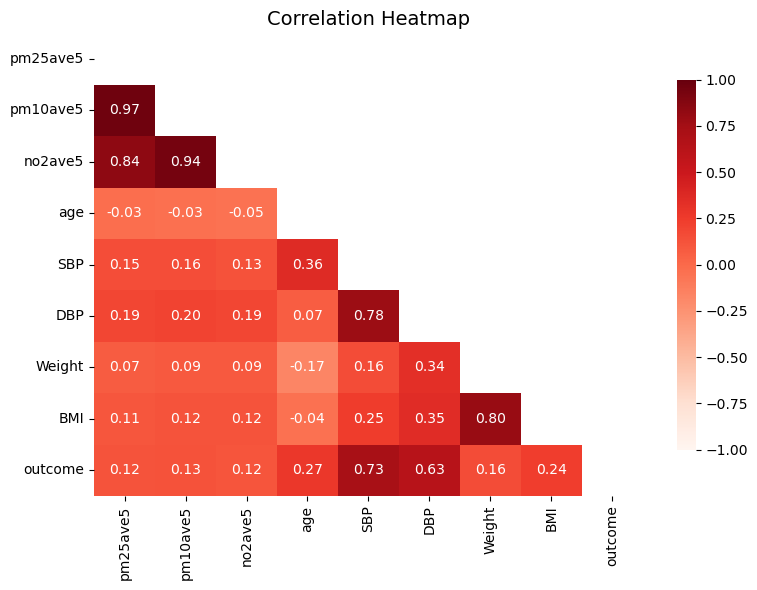

In [61]:
numeric_vars = ['pm25ave5', 'pm10ave5', 'no2ave5',
                'age', 'SBP', 'DBP', 'Weight', 'BMI',
                'outcome']  
df_numeric = data[numeric_vars]
# Compute correlation matrix
corr = df_numeric.corr(method='pearson')
# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, 
            mask=mask, 
            cmap='Reds',     
            annot=True,       
            fmt=".2f",       
            vmin=-1, vmax=1,  
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


In [62]:
# tuning random forest some more
X_all = data.drop(columns = 'outcome')
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size = 0.2, stratify = y, random_state = 42)
optimized_rf = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', max_depth = 13, min_samples_leaf=2, min_samples_split=5, max_features = 'sqrt', random_state = 42)
optimized_rf.fit(X_train_all, y_train_all)
all_pred = optimized_rf.predict(X_train_all)
f1 = f1_score(y_train, all_pred)
print(f1)
all_pred_test = optimized_rf.predict(X_test_all)
f1_test = f1_score(y_test, all_pred_test)
print(f1_test)
optimized_rf.feature_importances_

0.9492508968136738
0.891477885652643


array([0.01825028, 0.00611442, 0.04117618, 0.00161129, 0.00499314,
       0.00341321, 0.00113973, 0.00087462, 0.00308886, 0.00253496,
       0.00196419, 0.00098169, 0.00208875, 0.00135158, 0.01178991,
       0.01436291, 0.02615853, 0.41545359, 0.27008554, 0.01373207,
       0.01626932, 0.01248335, 0.01312826, 0.0095005 , 0.00193364,
       0.00155738, 0.01110232, 0.01506466, 0.01151858, 0.06627655])

In [63]:
param_grid = {
    'max_depth': [5,6,7,8,9,10,11,12,13],
    'min_samples_split': [2,3,4,5,6,7,8],
    'min_samples_leaf': [1,2,3,4,5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train_all, y_train_all)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)


'param_grid = {\n    \'max_depth\': [5,6,7,8,9,10,11,12,13],\n    \'min_samples_split\': [2,3,4,5,6,7,8],\n    \'min_samples_leaf\': [1,2,3,4,5],\n    \'max_features\': [\'sqrt\', \'log2\']\n}\n\nrf = RandomForestClassifier(random_state=42)\n\ngrid_search = GridSearchCV(estimator=rf,\n                           param_grid=param_grid,\n                           cv=5,\n                           scoring=\'f1\',\n                           n_jobs=-1,\n                           verbose=1)\n\ngrid_search.fit(X_train_all, y_train_all)\n\nprint("Best parameters:", grid_search.best_params_)\nprint("Best F1 score:", grid_search.best_score_)'

In [64]:
best_rf_all = RandomForestClassifier(max_depth = 13, max_features = 'log2', min_samples_leaf = 1, min_samples_split = 5)
best_rf_all.fit(X_train_all, y_train_all)
best_rf_pred_test = best_rf_all.predict(X_test_all)
best_rf_f1_test = f1_score(y_test_all, best_rf_pred_test)
print(best_rf_f1_test)

0.8942838225557272


In [65]:
best_model.fit(X_train_all, y_train_all)
xgb_pred = best_model.predict(X_train_all)
xgb_f1 = f1_score(y_train_all, xgb_pred)
print(xgb_f1)
xgb_pred_test = best_model.predict(X_test_all)
xgb_f1_test = f1_score(y_test_all, xgb_pred_test)
print(xgb_f1_test)

0.8988887064104669
0.895541958041958


In [66]:
def objective3(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 600),
        "max_depth": trial.suggest_int("max_depth", 10, 14),
        "learning_rate": trial.suggest_float("learning_rate", 0.08, 0.12, step=0.01),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.85, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.3, 2.5),
        "random_state": 42,
        "n_jobs": -1,
    }

    model = XGBClassifier(**params, eval_metric="logloss")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, X_train_all, y_train, 
                             scoring="f1", cv=cv, n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective3, n_trials=50)

print("Best params:", study.best_params)
print("Best F1:", study.best_value)


[I 2025-08-25 13:48:56,170] A new study created in memory with name: no-name-221f355b-ef56-4349-895a-6b40d339afd8
[I 2025-08-25 13:49:01,940] Trial 0 finished with value: 0.8909011230524282 and parameters: {'n_estimators': 462, 'max_depth': 13, 'learning_rate': 0.08, 'subsample': 0.856037727936757, 'colsample_bytree': 0.988293208719179, 'gamma': 3.857662250432099, 'min_child_weight': 4, 'reg_alpha': 1.385749270981559, 'reg_lambda': 1.344020304404527, 'scale_pos_weight': 1.8729207368135028}. Best is trial 0 with value: 0.8909011230524282.
[I 2025-08-25 13:49:06,853] Trial 1 finished with value: 0.888842989209091 and parameters: {'n_estimators': 455, 'max_depth': 11, 'learning_rate': 0.09, 'subsample': 0.8648461817680945, 'colsample_bytree': 0.8891605458870412, 'gamma': 0.6076802922305441, 'min_child_weight': 9, 'reg_alpha': 1.4441092731289078, 'reg_lambda': 1.151577712974262, 'scale_pos_weight': 1.3594663744691664}. Best is trial 0 with value: 0.8909011230524282.
[I 2025-08-25 13:49:10,

Best params: {'n_estimators': 397, 'max_depth': 12, 'learning_rate': 0.09, 'subsample': 0.888036006173316, 'colsample_bytree': 0.9256750800242262, 'gamma': 4.348642737551747, 'min_child_weight': 5, 'reg_alpha': 0.3905571267251695, 'reg_lambda': 1.0653187735231828, 'scale_pos_weight': 1.3971461972834824}
Best F1: 0.8949494028415573


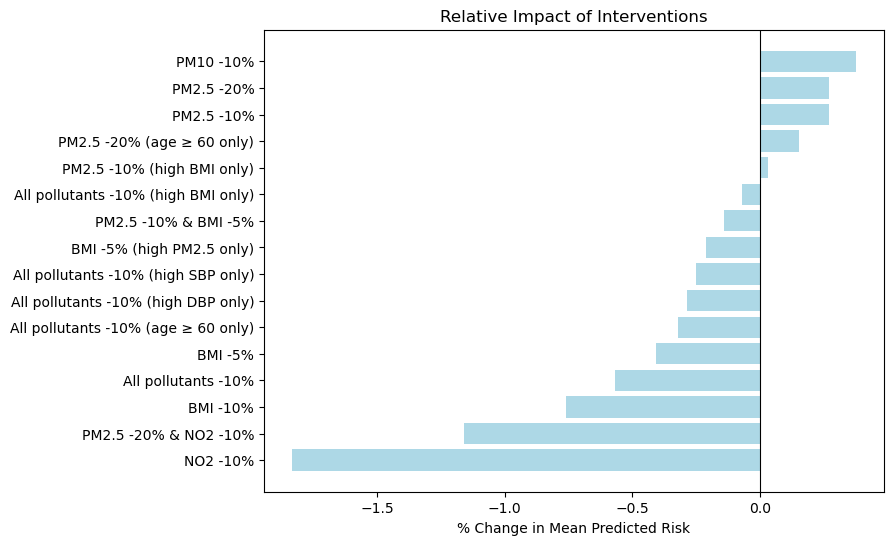

In [67]:
interventions = {
    # Pollution reductions
    "PM2.5 -10%": lambda X: X.assign(pm25ave5=X['pm25ave5'] * 0.9),
    "PM2.5 -20%": lambda X: X.assign(pm25ave5=X['pm25ave5'] * 0.8),
    "PM10 -10%": lambda X: X.assign(pm10ave5=X['pm10ave5'] * 0.9),
    "NO2 -10%": lambda X: X.assign(no2ave5=X['no2ave5'] * 0.9),

    # Demographic changes
    "BMI -5%": lambda X: X.assign(BMI=X['BMI'] * 0.95),
    "BMI -10%": lambda X: X.assign(BMI=X['BMI'] * 0.90),

    # Targeted subgroups
    "PM2.5 -10% (high BMI only)": lambda X: X.assign(
        pm25ave5=np.where(X['BMI'] >= 30, X['pm25ave5'] * 0.9, X['pm25ave5'])
    ),
    "PM2.5 -20% (age ≥ 60 only)": lambda X: X.assign(
        pm25ave5=np.where(X['age'] >= 60, X['pm25ave5'] * 0.8, X['pm25ave5'])
    ),
    "BMI -5% (high PM2.5 only)": lambda X: X.assign(
        BMI=np.where(X['pm25ave5'] >= X['pm25ave5'].median(), X['BMI'] * 0.95, X['BMI'])
    ),

    # Combined interventions
    "PM2.5 -10% & BMI -5%": lambda X: X.assign(
        pm25ave5=X['pm25ave5'] * 0.9,
        BMI=X['BMI'] * 0.95
    ),
    "PM2.5 -20% & NO2 -10%": lambda X: X.assign(
        pm25ave5=X['pm25ave5'] * 0.8,
        no2ave5=X['no2ave5'] * 0.9
    ),
    "All pollutants -10%": lambda X: X.assign(
        pm25ave5=X['pm25ave5'] * 0.9,
        pm10ave5=X['pm10ave5'] * 0.9,
        no2ave5=X['no2ave5'] * 0.9
    ),

    # All pollutants reductions for specific subgroups
    "All pollutants -10% (high BMI only)": lambda X: X.assign(
        pm25ave5=np.where(X['BMI'] >= 30, X['pm25ave5'] * 0.9, X['pm25ave5']),
        pm10ave5=np.where(X['BMI'] >= 30, X['pm10ave5'] * 0.9, X['pm10ave5']),
        no2ave5=np.where(X['BMI'] >= 30, X['no2ave5'] * 0.9, X['no2ave5'])
    ),
    "All pollutants -10% (age ≥ 60 only)": lambda X: X.assign(
        pm25ave5=np.where(X['age'] >= 60, X['pm25ave5'] * 0.9, X['pm25ave5']),
        pm10ave5=np.where(X['age'] >= 60, X['pm10ave5'] * 0.9, X['pm10ave5']),
        no2ave5=np.where(X['age'] >= 60, X['no2ave5'] * 0.9, X['no2ave5'])
    ),
    "All pollutants -10% (high DBP only)": lambda X: X.assign(
        pm25ave5=np.where(X['DBP'] >= X['DBP'].median(), X['pm25ave5'] * 0.9, X['pm25ave5']),
        pm10ave5=np.where(X['DBP'] >= X['DBP'].median(), X['pm10ave5'] * 0.9, X['pm10ave5']),
        no2ave5=np.where(X['DBP'] >= X['DBP'].median(), X['no2ave5'] * 0.9, X['no2ave5'])
    ),
    "All pollutants -10% (high SBP only)": lambda X: X.assign(
        pm25ave5=np.where(X['SBP'] >= X['SBP'].median(), X['pm25ave5'] * 0.9, X['pm25ave5']),
        pm10ave5=np.where(X['SBP'] >= X['SBP'].median(), X['pm10ave5'] * 0.9, X['pm10ave5']),
        no2ave5=np.where(X['SBP'] >= X['SBP'].median(), X['no2ave5'] * 0.9, X['no2ave5'])
    )
}

# Run interventions and compare
results = []
baseline_preds = best_model.predict_proba(X_train_all)[:, 1]
baseline_mean = baseline_preds.mean()

for name, func in interventions.items():
    X_new = func(X_train_all.copy())
    preds_new = best_model.predict_proba(X_new)[:, 1]
    mean_new = preds_new.mean()
    change_pct = (mean_new - baseline_mean) / baseline_mean * 100
    results.append({"Intervention": name, "Change (%)": change_pct})

results_df = pd.DataFrame(results).sort_values("Change (%)")

# Plot results
plt.figure(figsize=(8, 6))
plt.barh(results_df["Intervention"], results_df["Change (%)"], color='lightblue')
plt.xlabel("% Change in Mean Predicted Risk")
plt.title("Relative Impact of Interventions")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


In [68]:
# EDA
data.groupby('outcome')[['age', 'BMI', 'SBP', 'DBP']].mean()

,age,BMI,SBP,DBP
outcome,,,,
0,53.226966,24.232210,115.749689,72.535270
1,60.374354,26.037281,146.774048,88.198838


<Axes: xlabel='outcome', ylabel='BMI'>

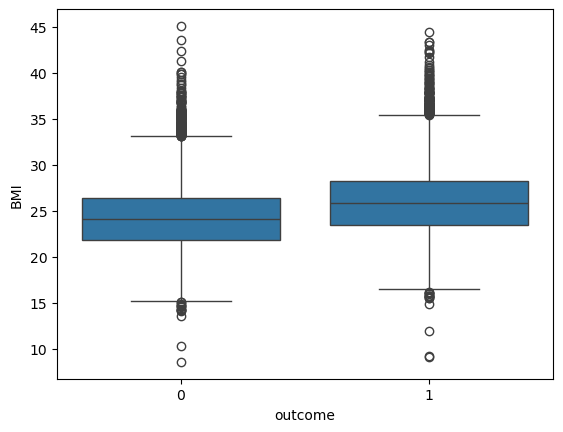

In [69]:
sns.boxplot(x='outcome', y='BMI', data=data)

<Axes: xlabel='outcome', ylabel='age'>

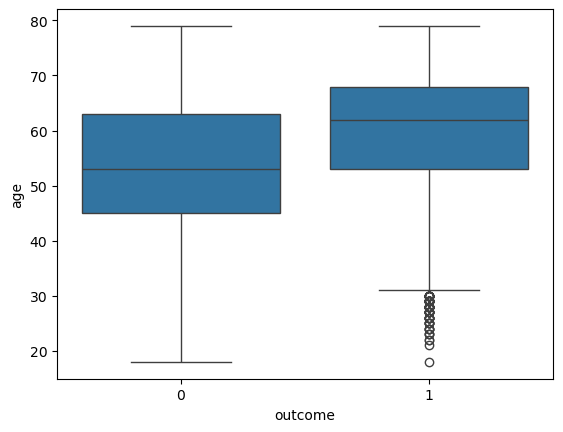

In [70]:
sns.boxplot(x = 'outcome', y = 'age', data = data)

<Axes: xlabel='outcome', ylabel='SBP'>

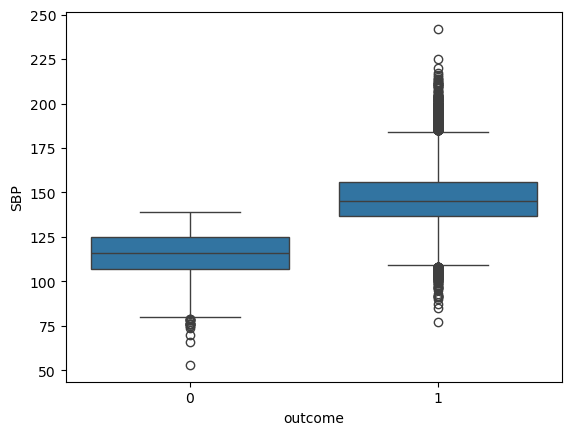

In [71]:
sns.boxplot(x = 'outcome', y = 'SBP', data = data)

<Axes: xlabel='outcome', ylabel='DBP'>

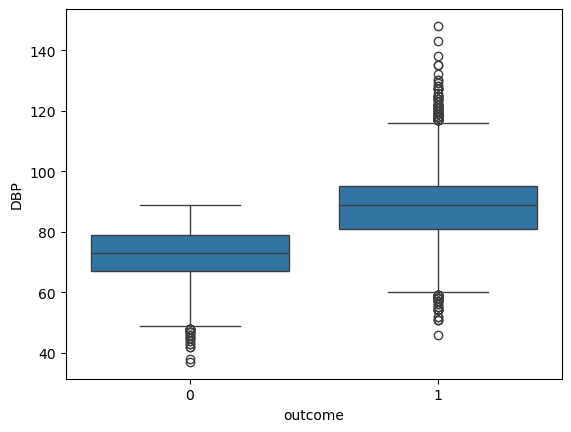

In [72]:
sns.boxplot(x = 'outcome', y = 'DBP', data = data)

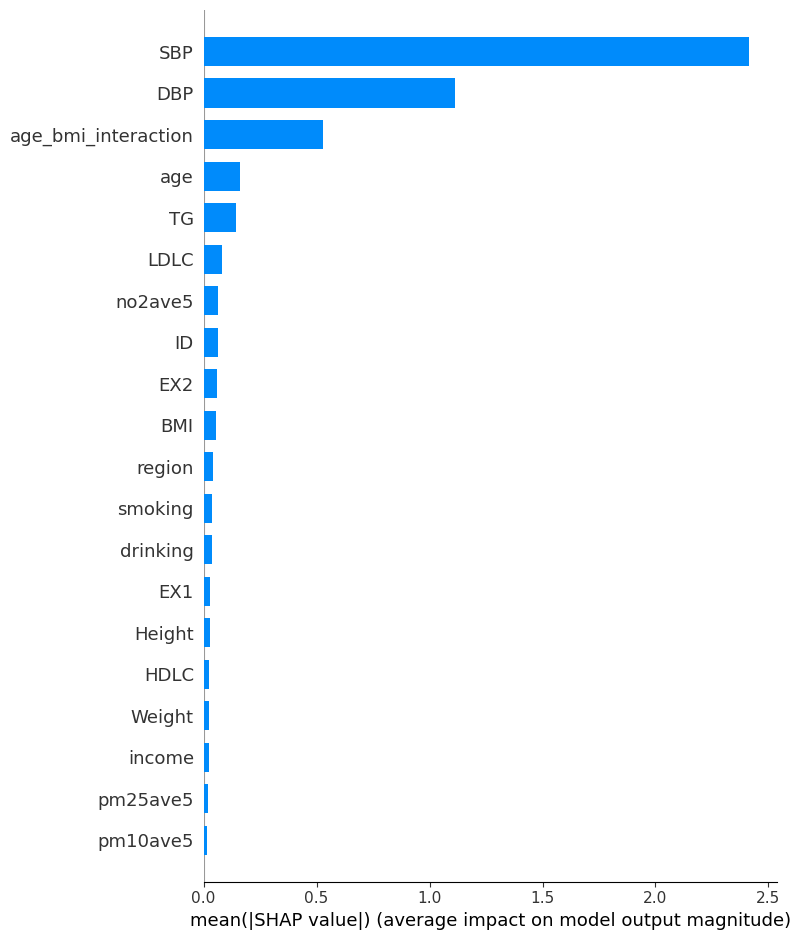

In [96]:
import shap

# Explain model predictions
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_all)
# SHAP summary plot
shap.summary_plot(shap_values, X_train_all, plot_type="bar")


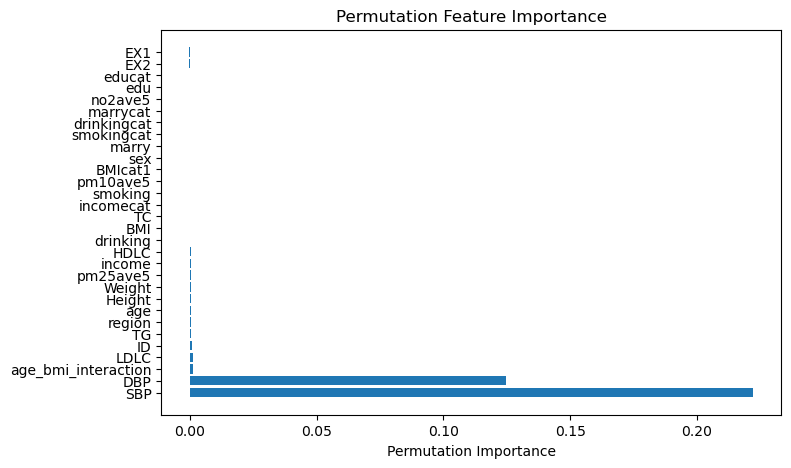

                Feature  Importance
17                  SBP    0.222175
18                  DBP    0.124603
29  age_bmi_interaction    0.001213
22                 LDLC    0.001092
0                    ID    0.000659
20                   TG    0.000482
1                region    0.000426
2                   age    0.000354
14               Height    0.000275
15               Weight    0.000223


In [98]:
from sklearn.inspection import permutation_importance
result = permutation_importance(best_model, X_train_all, y_train, 
                                n_repeats=10, random_state=42)

perm_importance = pd.DataFrame({
    "Feature": X_train_all.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(perm_importance["Feature"], perm_importance["Importance"])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance")
plt.show()

print(perm_importance.head(10))


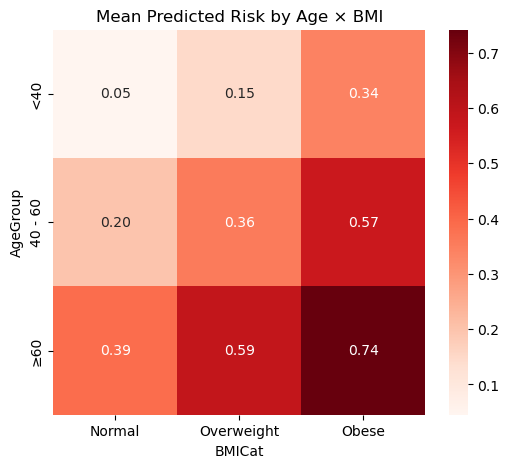

In [99]:
# Add subgroup bins
X_subgroup = X_train_all.copy()
X_subgroup["predicted_risk"] = best_model.predict_proba(X_train_all)[:,1]

# Age bins
X_subgroup["AgeGroup"] = pd.cut(X_subgroup["age"], bins=[0,40,60,100], labels=["<40","40 - 60","≥60"])
# BMI bins
X_subgroup["BMICat"] = pd.cut(X_subgroup["BMI"], bins=[0,25,30,100], labels=["Normal","Overweight","Obese"])

# Average risk by subgroup
heatmap_data = X_subgroup.groupby(["AgeGroup","BMICat"])["predicted_risk"].mean().unstack()

import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(heatmap_data, annot=True, cmap="Reds", fmt=".2f")
plt.title("Mean Predicted Risk by Age × BMI")
plt.show()


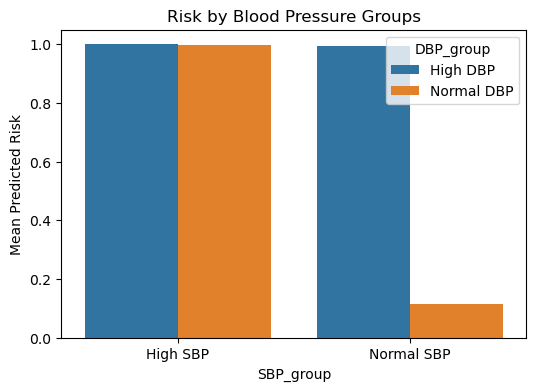

    SBP_group   DBP_group  predicted_risk
0    High SBP    High DBP        0.999884
1    High SBP  Normal DBP        0.998309
2  Normal SBP    High DBP        0.994882
3  Normal SBP  Normal DBP        0.115250


In [100]:
# Add high/normal BP groups
X_subgroup["SBP_group"] = np.where(X_subgroup["SBP"]>=140, "High SBP", "Normal SBP")
X_subgroup["DBP_group"] = np.where(X_subgroup["DBP"]>=90, "High DBP", "Normal DBP")

# Compare average risk
bp_groups = X_subgroup.groupby(["SBP_group","DBP_group"])["predicted_risk"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x="SBP_group", y="predicted_risk", hue="DBP_group", data=bp_groups)
plt.ylabel("Mean Predicted Risk")
plt.title("Risk by Blood Pressure Groups")
plt.show()

print(bp_groups)


In [101]:
log_model.fit(X_train_more, y_train)
log_pred_more = log_model.predict(X_train_more)
f1_log_more = f1_score(y_train, log_pred_more)
print(f1_log_more)
log_pred_more_test = log_model.predict(X_test_more)
f1_more_test = f1_score(y_test, log_pred_more_test)
f1_more_test

0.817434831885153


/Users/danielqian/anaconda3/envs/stat303_conda_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8132811042715912

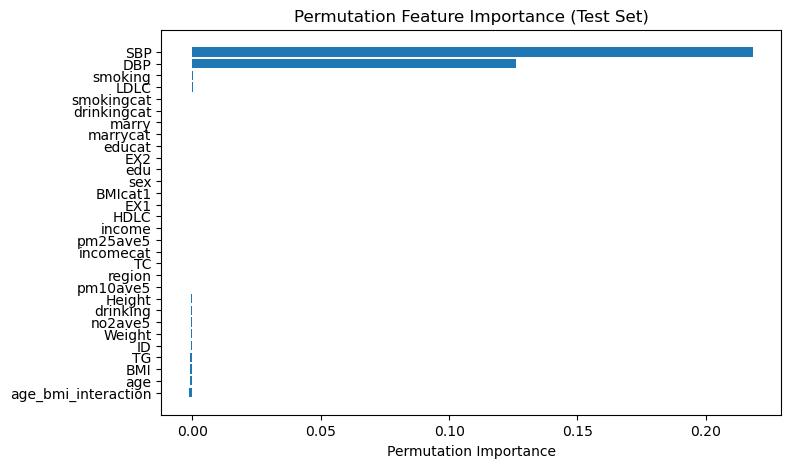

        Feature  Importance
17          SBP    0.218406
18          DBP    0.125953
10      smoking    0.000253
22         LDLC    0.000170
11   smokingcat    0.000000
13  drinkingcat    0.000000
6         marry    0.000000
7      marrycat    0.000000
5        educat   -0.000017
25          EX2   -0.000022


In [103]:
# Compute permutation importance on test set
result = permutation_importance(
    best_model, X_test_all, y_test_all, 
    n_repeats=30, random_state=42, n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X_test_all.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(perm_importance["Feature"], perm_importance["Importance"])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance (Test Set)")
plt.gca().invert_yaxis()
plt.show()

print(perm_importance.head(10))


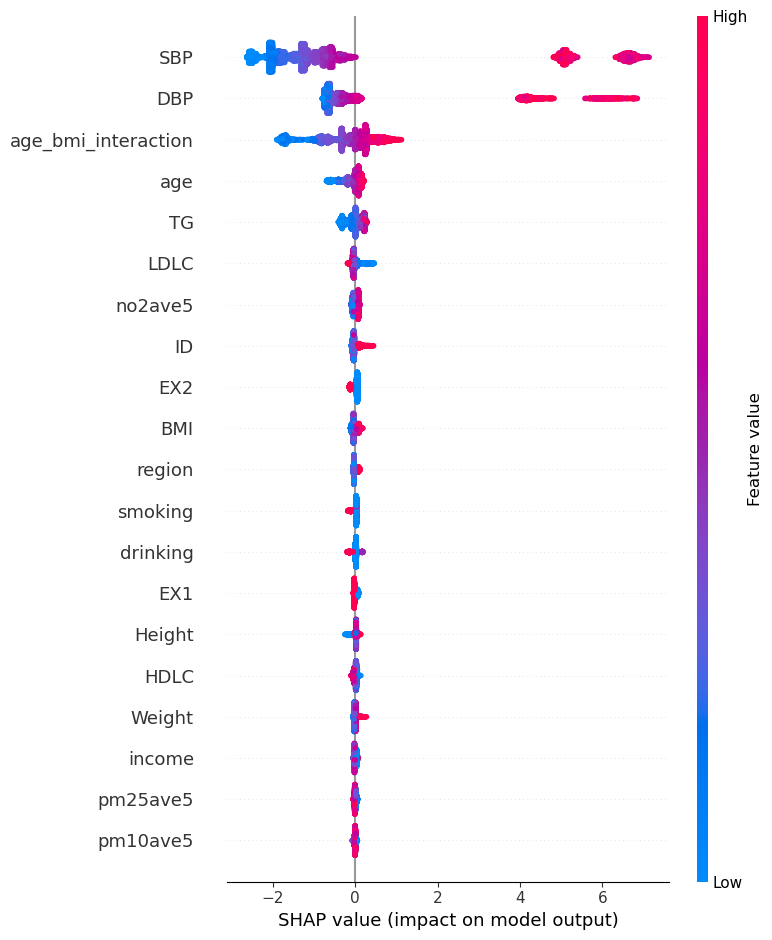

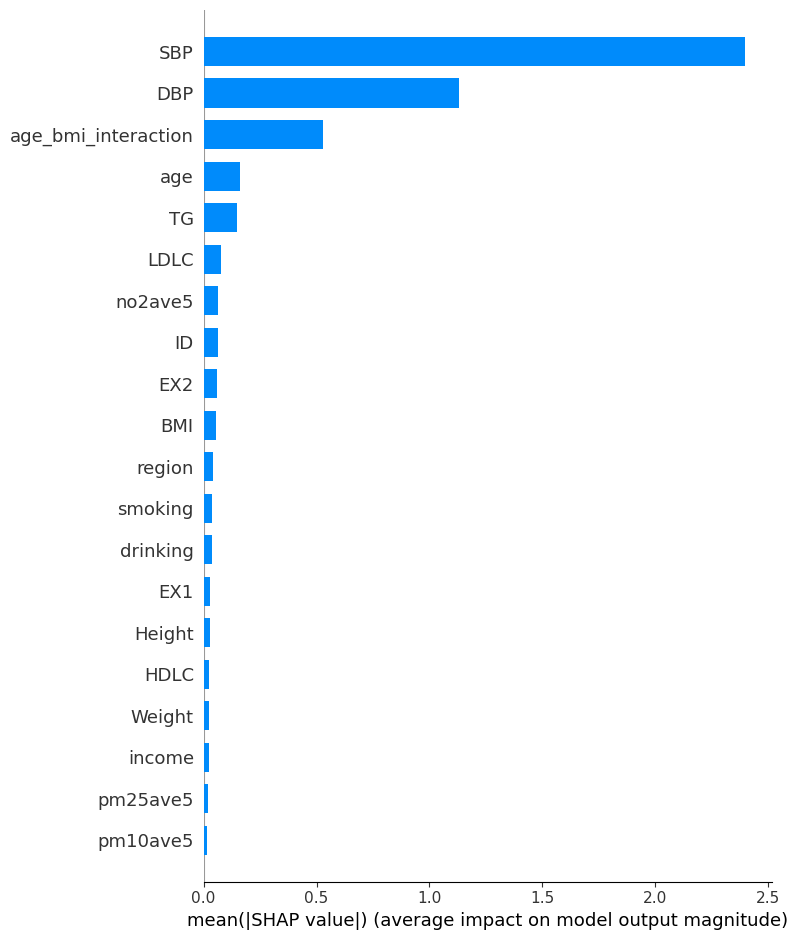

In [79]:
# Initialize Tree SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test_all)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test_all)

# Bar plot version (mean absolute importance)
shap.summary_plot(shap_values, X_test_all, plot_type="bar")


<Axes: xlabel='BMI', ylabel='Count'>

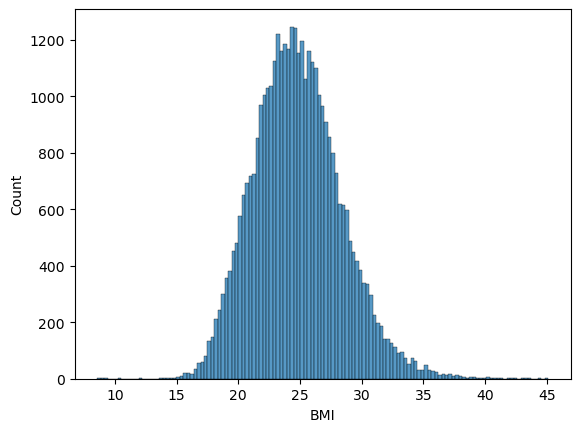

In [80]:
sns.histplot(data = data, x = 'BMI')

<Axes: ylabel='Count'>

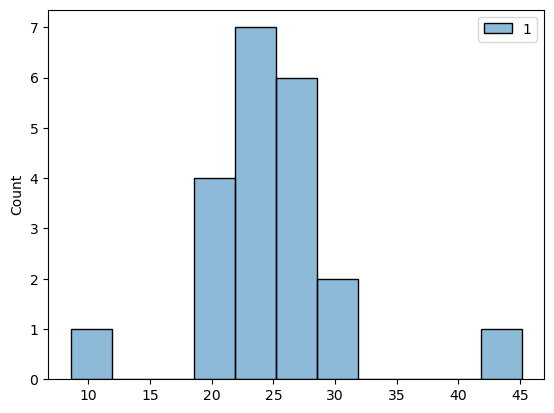

In [81]:
bmi_binned = pd.qcut(data['BMI'], 20, retbins = True)
sns.histplot(bmi_binned)

<Axes: xlabel='Weight', ylabel='Count'>

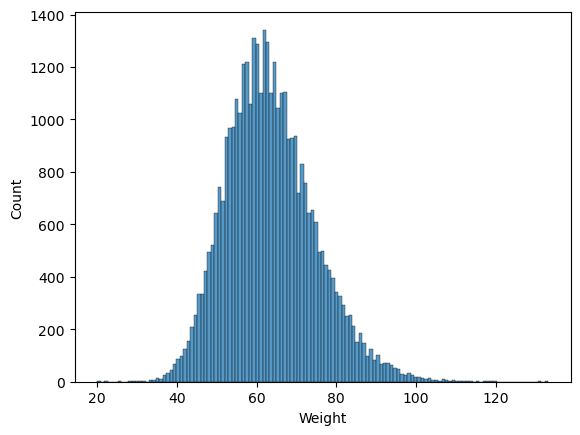

In [82]:
sns.histplot(data = data, x = 'Weight')

<Axes: ylabel='Count'>

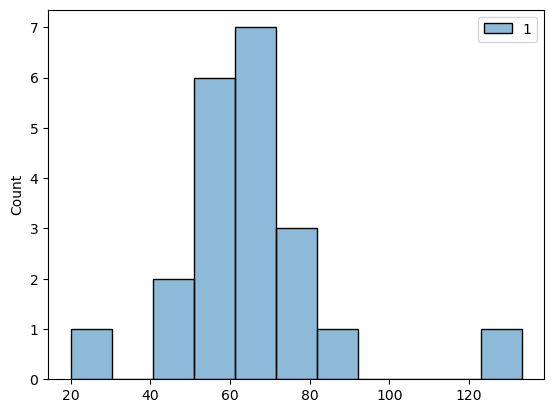

In [83]:
bmi_binned = pd.qcut(data['Weight'], 20, retbins = True)
sns.histplot(bmi_binned)

<Axes: xlabel='age', ylabel='Count'>

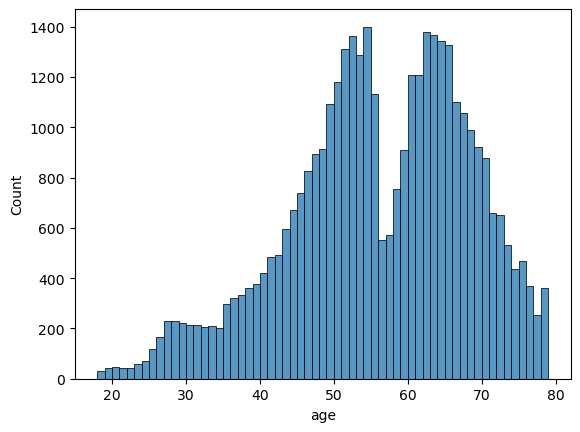

In [84]:
sns.histplot(data = data, x = 'age')

<Axes: ylabel='Count'>

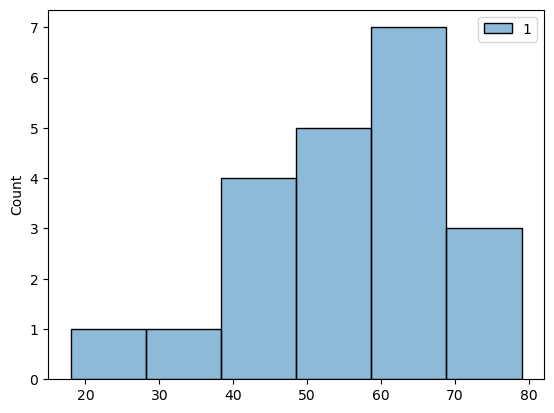

In [85]:
age_binned = pd.qcut(data['age'], 20, retbins = True)
sns.histplot(age_binned)

In [90]:
param_grid = {
    'max_depth': [5,6,7,8,9,10,11,12,13],
    'min_samples_split': [2,3,4,5,6,7,8],
    'min_samples_leaf': [1,2,3,4,5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='f1',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train_all, y_train_all)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)
cv_results_many = pd.DataFrame(grid_search.cv_results_)
pd.set_option('display.float_format', '{:.6f}'.format) 
cv_results[["mean_test_score"]]
# unsure if these actually go together
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 630 candidates, totalling 3150 fits


/Users/danielqian/anaconda3/envs/stat303_conda_env/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters: {'max_depth': 13, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5}
Best F1 score: 0.8953776637014332
{'max_depth': 13, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5}
0.8953776637014332
RandomForestClassifier(max_depth=13, max_features='log2', min_samples_split=5,
                       random_state=42)


In [95]:
from sklearn.metrics import f1_score
optimized_rf = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', max_depth = 13, min_samples_leaf=1, min_samples_split=5, max_features = 'log2', random_state = 42)
optimized_rf.fit(X_train_all, y_train_all)
test_pred = optimized_rf.predict(X_test_all)
f1 = f1_score(y_test_all, test_pred)
print(f1)
print(optimized_rf.feature_importances_)
feature_names = X_train_all.columns 
feature_names

0.8905172413793103
[0.02063119 0.00592687 0.04263636 0.00194865 0.0059304  0.00496219
 0.00171785 0.00124516 0.0037201  0.0026534  0.00256208 0.00122276
 0.00231257 0.00152437 0.01298572 0.01674009 0.02745962 0.41330699
 0.24743377 0.01499463 0.01741717 0.01324997 0.01414818 0.01140612
 0.00227262 0.00180823 0.0113501  0.01702879 0.01282614 0.0665779 ]


Index(['ID', 'region', 'age', 'sex', 'edu', 'educat', 'marry', 'marrycat',
       'income', 'incomecat', 'smoking', 'smokingcat', 'drinking',
       'drinkingcat', 'Height', 'Weight', 'BMI', 'SBP', 'DBP', 'TC', 'TG',
       'HDLC', 'LDLC', 'BMIcat1', 'EX1', 'EX2', 'pm25ave5', 'pm10ave5',
       'no2ave5', 'age_bmi_interaction'],
      dtype='object')

In [110]:
X_train_SBP_reduced = X_train_all.copy()
high_age_mask = X_train_bmi_reduced['age'] >= 60
X_train_SBP_reduced.loc[high_age_mask, 'SBP'] -= 5
y_pred_SBP = best_model.predict_proba(X_train_SBP_reduced)[:, 1]
SBP_risk = y_pred_SBP.mean()
SBP_change = (SBP_risk - baseline_risk) / baseline_risk * 100
print(f"SBP reduction risk change: {SBP_change:.2f}%")

SBP reduction risk change: -6.96%


In [111]:
X_train_SBP_reduced = X_train_all.copy()
high_age_mask = X_train_bmi_reduced['age'] >= 60
X_train_SBP_reduced.loc[high_age_mask, 'SBP'] -= 10
y_pred_SBP = best_model.predict_proba(X_train_SBP_reduced)[:, 1]
SBP_risk = y_pred_SBP.mean()
SBP_change = (SBP_risk - baseline_risk) / baseline_risk * 100
print(f"SBP reduction risk change: {SBP_change:.2f}%")

SBP reduction risk change: -12.84%


In [112]:
X_train_DBP_reduced = X_train_all.copy()
high_age_mask = X_train_DBP_reduced['age'] >= 60
X_train_DBP_reduced.loc[high_age_mask, 'DBP'] -= 5
y_pred_DBP = best_model.predict_proba(X_train_DBP_reduced)[:, 1]
DBP_risk = y_pred_DBP.mean()
DBP_change = (DBP_risk - baseline_risk) / baseline_risk * 100
print(f"DBP reduction risk change: {DBP_change:.2f}%")

DBP reduction risk change: -2.17%


In [113]:
X_train_DBP_reduced = X_train_all.copy()
high_age_mask = X_train_DBP_reduced['age'] >= 60
X_train_DBP_reduced.loc[high_age_mask, 'DBP'] -= 10
y_pred_DBP = best_model.predict_proba(X_train_DBP_reduced)[:, 1]
DBP_risk = y_pred_DBP.mean()
DBP_change = (DBP_risk - baseline_risk) / baseline_risk * 100
print(f"DBP reduction risk change: {DBP_change:.2f}%")

DBP reduction risk change: -3.09%
